## <center><b> Statistical analysis

### <center><b>Loading data

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import mannwhitneyu, chi2_contingency
from dotenv import load_dotenv

In [2]:
load_dotenv('vars.env')
DATA_PATH = os.getenv("DATA_PATH")
DEMOGRAPHICS = os.getenv("DEMOGRAPHICS")
STAT_PATH = os.getenv("STAT_PATH")

In [5]:
# Collect paths from patient records
patients = []
vital_base = os.path.join(DATA_PATH, 'Vital data')
hs_base    = os.path.join(DATA_PATH, 'HemoSphere data')

for folder in sorted(os.listdir(vital_base)):
    vital_pad = os.path.join(vital_base, folder, 'vital.csv')
    hs_pad    = os.path.join(hs_base,    folder, 'hemosphere.csv')

    if os.path.exists(vital_pad) and os.path.exists(hs_pad):
        patients.append((vital_pad, hs_pad))

patient_ids = []
for vital_path, hs_path in patients:
    naam = os.path.basename(os.path.dirname(vital_path))
    patient_id = int(naam.replace('MARTINI_', ''))
    patient_ids.append(patient_id)

df_demo = pd.read_csv(os.path.join(DATA_PATH, DEMOGRAPHICS), sep=';')
df_final = df_demo[df_demo['Participant Id'].isin(patient_ids)].copy()

### <center><b>Defenition Normality plots

In [11]:
def test_normal_distribution(datasets):
    """
    Each variable gets a row with three diagnostics:
      1. Q-Q plot (with R²)
      2. Histogram with fitted normal curve
      3. Box plot
    """
    
    n = len(datasets)
    fig, axes = plt.subplots(n, 3, figsize=(18, 5 * n))
    # make axes indexing uniform when there is only one row
    if n == 1:
        axes = axes.reshape(1, 3)

    fig.suptitle('Normality Tests', fontsize=15, fontweight='bold', y=1.0)

    for i, (data, name) in enumerate(datasets):

        data = np.array(data, dtype=float)
        data = data[~np.isnan(data)].flatten()

        # Q-Q plot
        (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')

        axes[i, 0].plot(osm, osr, 'o', color='#378ADD', markersize=3, alpha=0.5)
        axes[i, 0].plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5)
        axes[i, 0].set_title(f'{name} — Q-Q Plot', fontweight='bold', loc='left')
        axes[i, 0].set_xlabel('Theoretical Quantiles')
        axes[i, 0].set_ylabel('Sample Quantiles')
        axes[i, 0].grid(True, alpha=0.2)
        axes[i, 0].text(
            0.05, 0.95,
            f'R² = {r**2:.4f}',
            transform=axes[i, 0].transAxes,
            fontsize=10, verticalalignment='top'
        )

        # Histogram
        axes[i, 1].hist(
            data, bins=40, color='#85B7EB', edgecolor='white',
            linewidth=0.5, density=True, alpha=0.8
        )
        x = np.linspace(data.min(), data.max(), 200)
        axes[i, 1].plot(x, stats.norm.pdf(x, data.mean(), data.std()), 'r-', linewidth=2)
        axes[i, 1].set_title(f'{name} — Histogram', fontweight='bold', loc='left')
        axes[i, 1].set_xlabel(name)
        axes[i, 1].set_ylabel('Density')
        axes[i, 1].grid(True, alpha=0.2)

        # Box plot
        axes[i, 2].boxplot(
            data, vert=True, patch_artist=True,
            boxprops=dict(facecolor='#85B7EB'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', markersize=4, markerfacecolor='#378ADD', alpha=0.5)
        )
        axes[i, 2].set_title(f'{name} — Box Plot', fontweight='bold', loc='left')
        axes[i, 2].set_ylabel(name)
        axes[i, 2].set_xticks([])
        axes[i, 2].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

### <center><b>Normality plots + Descriptive Statics for the whole Dataset

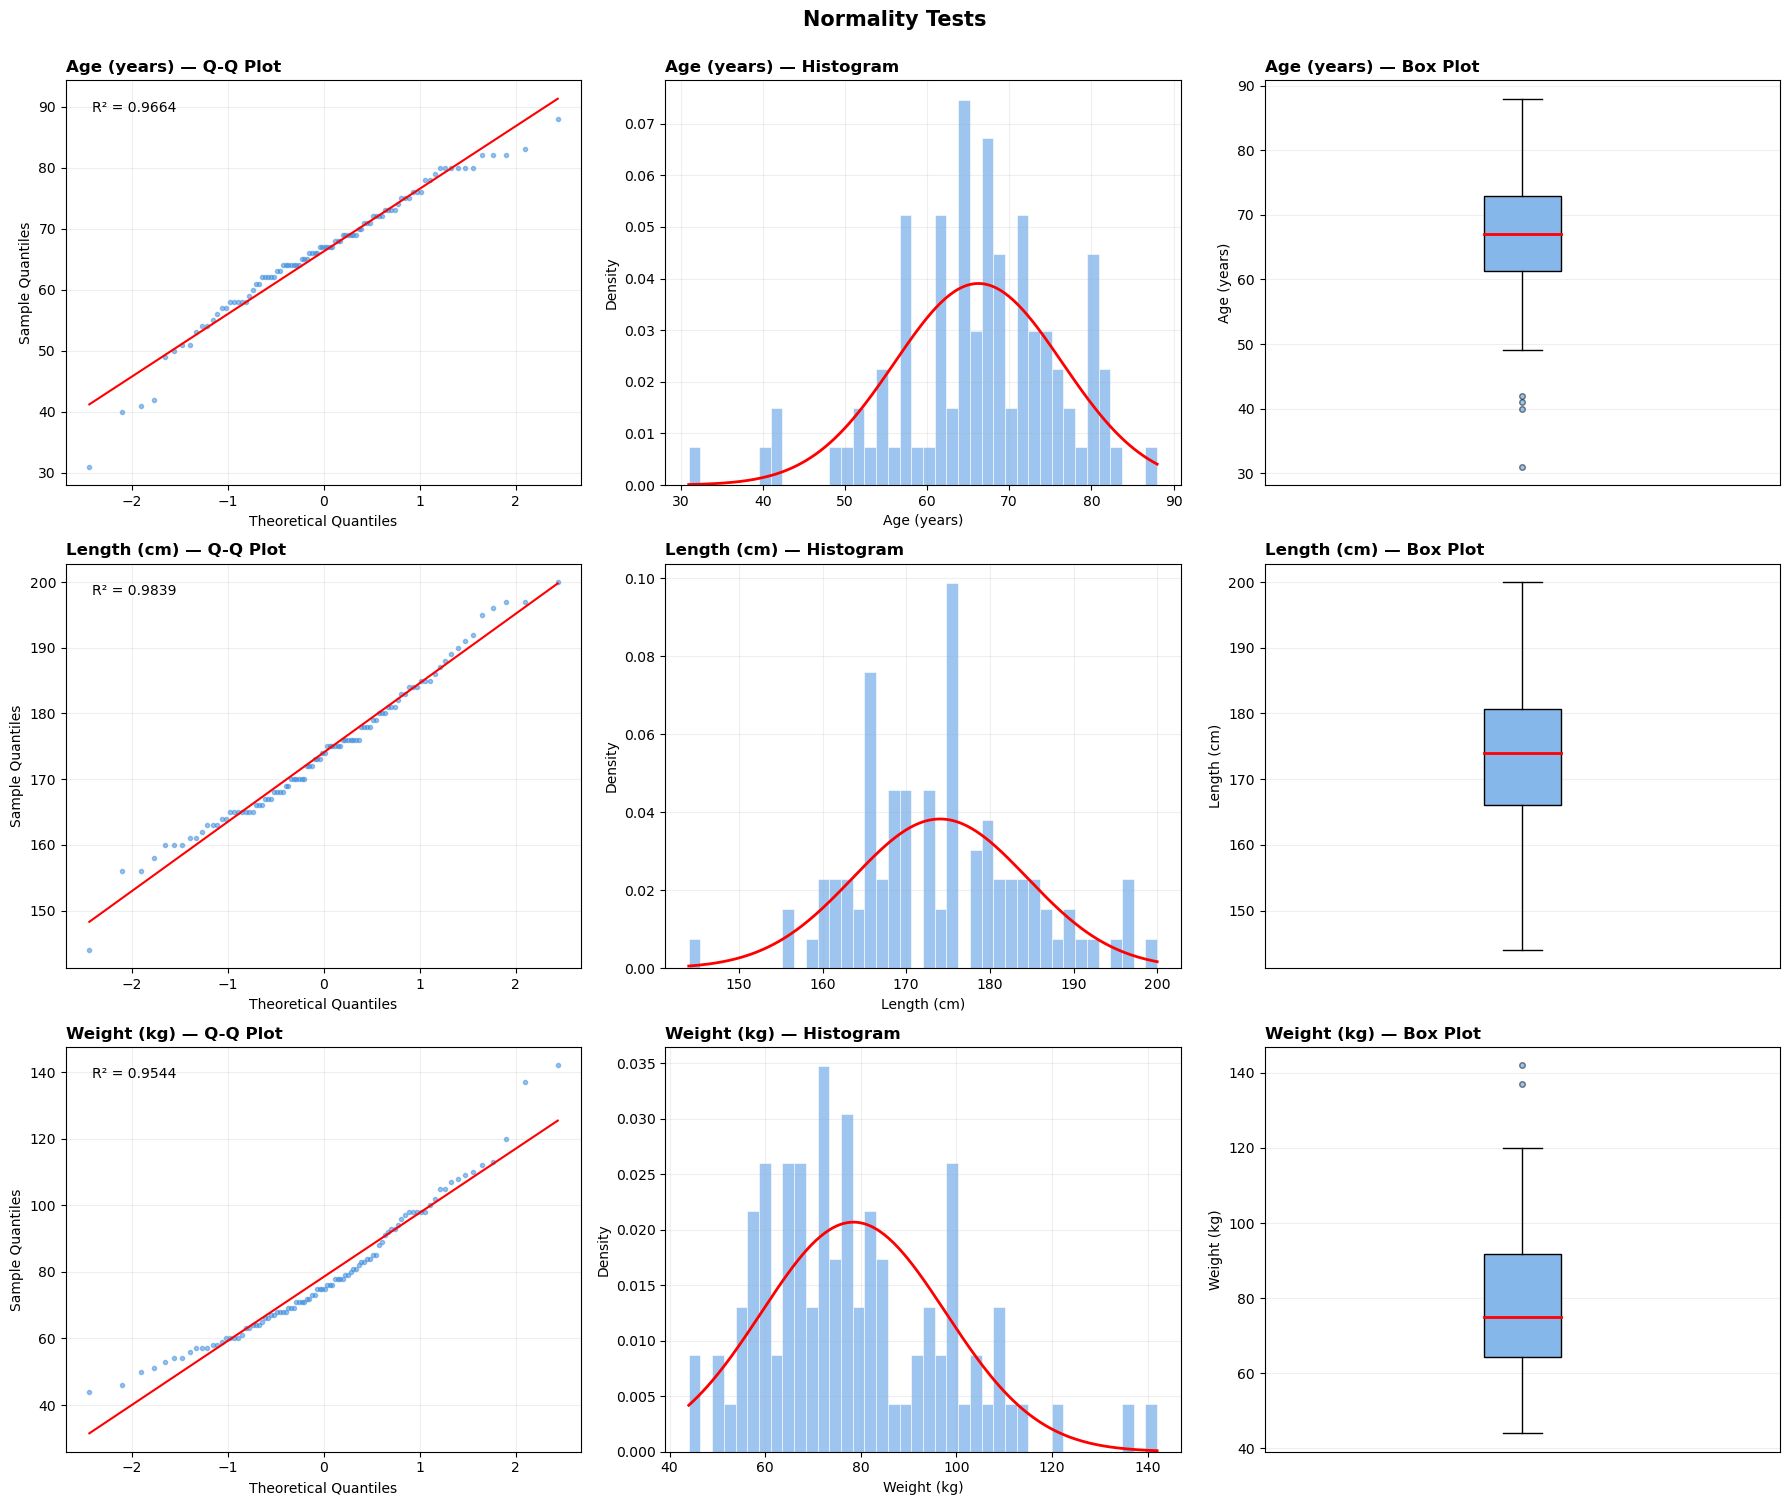

,Characteristic,Validation dataset (n=94)
0,"Age, mean ± SD, years",66.2 ± 10.3
1,"Height, mean ± SD, cm",174.0 ± 10.5
2,"Sex, number male (%)",39 (41.49)
3,"Weight, median (IQR), kg",75.0 (64.2-91.8)


In [12]:
# Normality tests for age, height, and weight
test_normal_distribution([
    (df_final['age_at_surgery'].dropna().values, 'Age (years)'),
    (df_final['dem_height'].dropna().values,     'Length (cm)'),
    (df_final['dem_weight'].dropna().values,     'Weight (kg)'),
])

# Summary table for demographics
summary = []

# Age — normaal verdeeld -> mean ± SD
data = df_final['age_at_surgery'].dropna()
summary.append({
    'Characteristic': 'Age, mean ± SD, years',
    'Validation': f'{data.mean():.1f} ± {data.std():.1f}'
})

data = df_final['dem_height'].dropna()
summary.append({
    'Characteristic': 'Height, mean ± SD, cm',
    'Validation': f'{data.mean():.1f} ± {data.std():.1f}'
})

sex = df_final['dem_sex'].map({'Male': 1, 'Female': 0})
n_total, n_male = sex.notna().sum(), (sex == 1).sum()
summary.append({
    'Characteristic': 'Sex, number male (%)',
    'Validation': f'{n_male} ({100 * n_male / n_total:.2f})'
})

data = df_final['dem_weight'].dropna()
summary.append({
    'Characteristic': 'Weight, median (IQR), kg',
    'Validation': f'{data.median():.1f} ({data.quantile(0.25):.1f}-{data.quantile(0.75):.1f})'
})

column_name = f'Validation dataset (n={len(df_final)})'
df_summary = pd.DataFrame(summary).rename(columns={'Validation': column_name})

display(df_summary)

### <center><b>Normality plots + Splitting of dataset for splitted Dataset

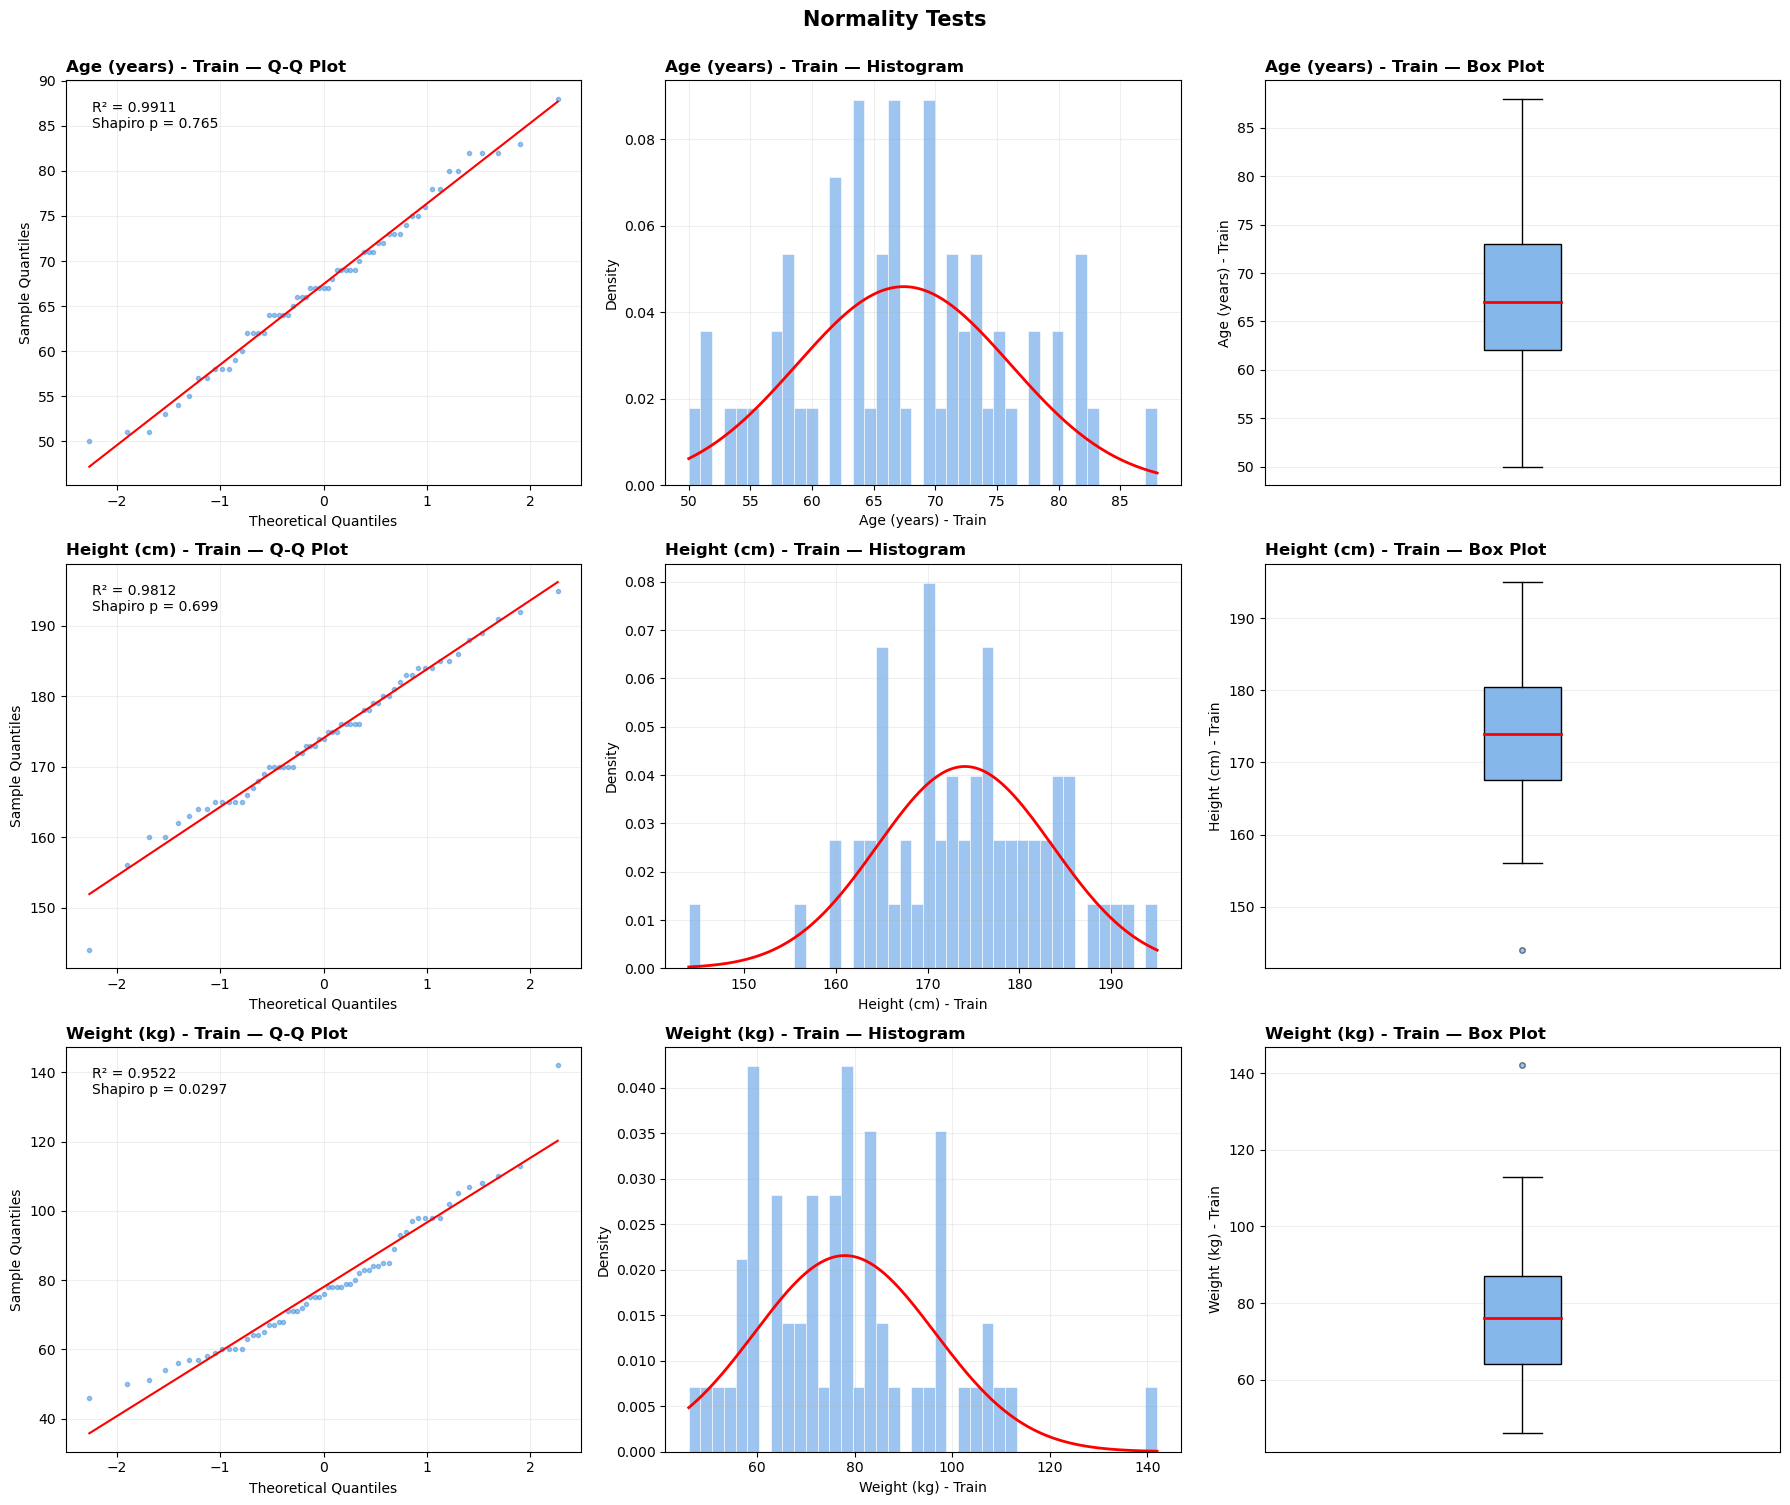

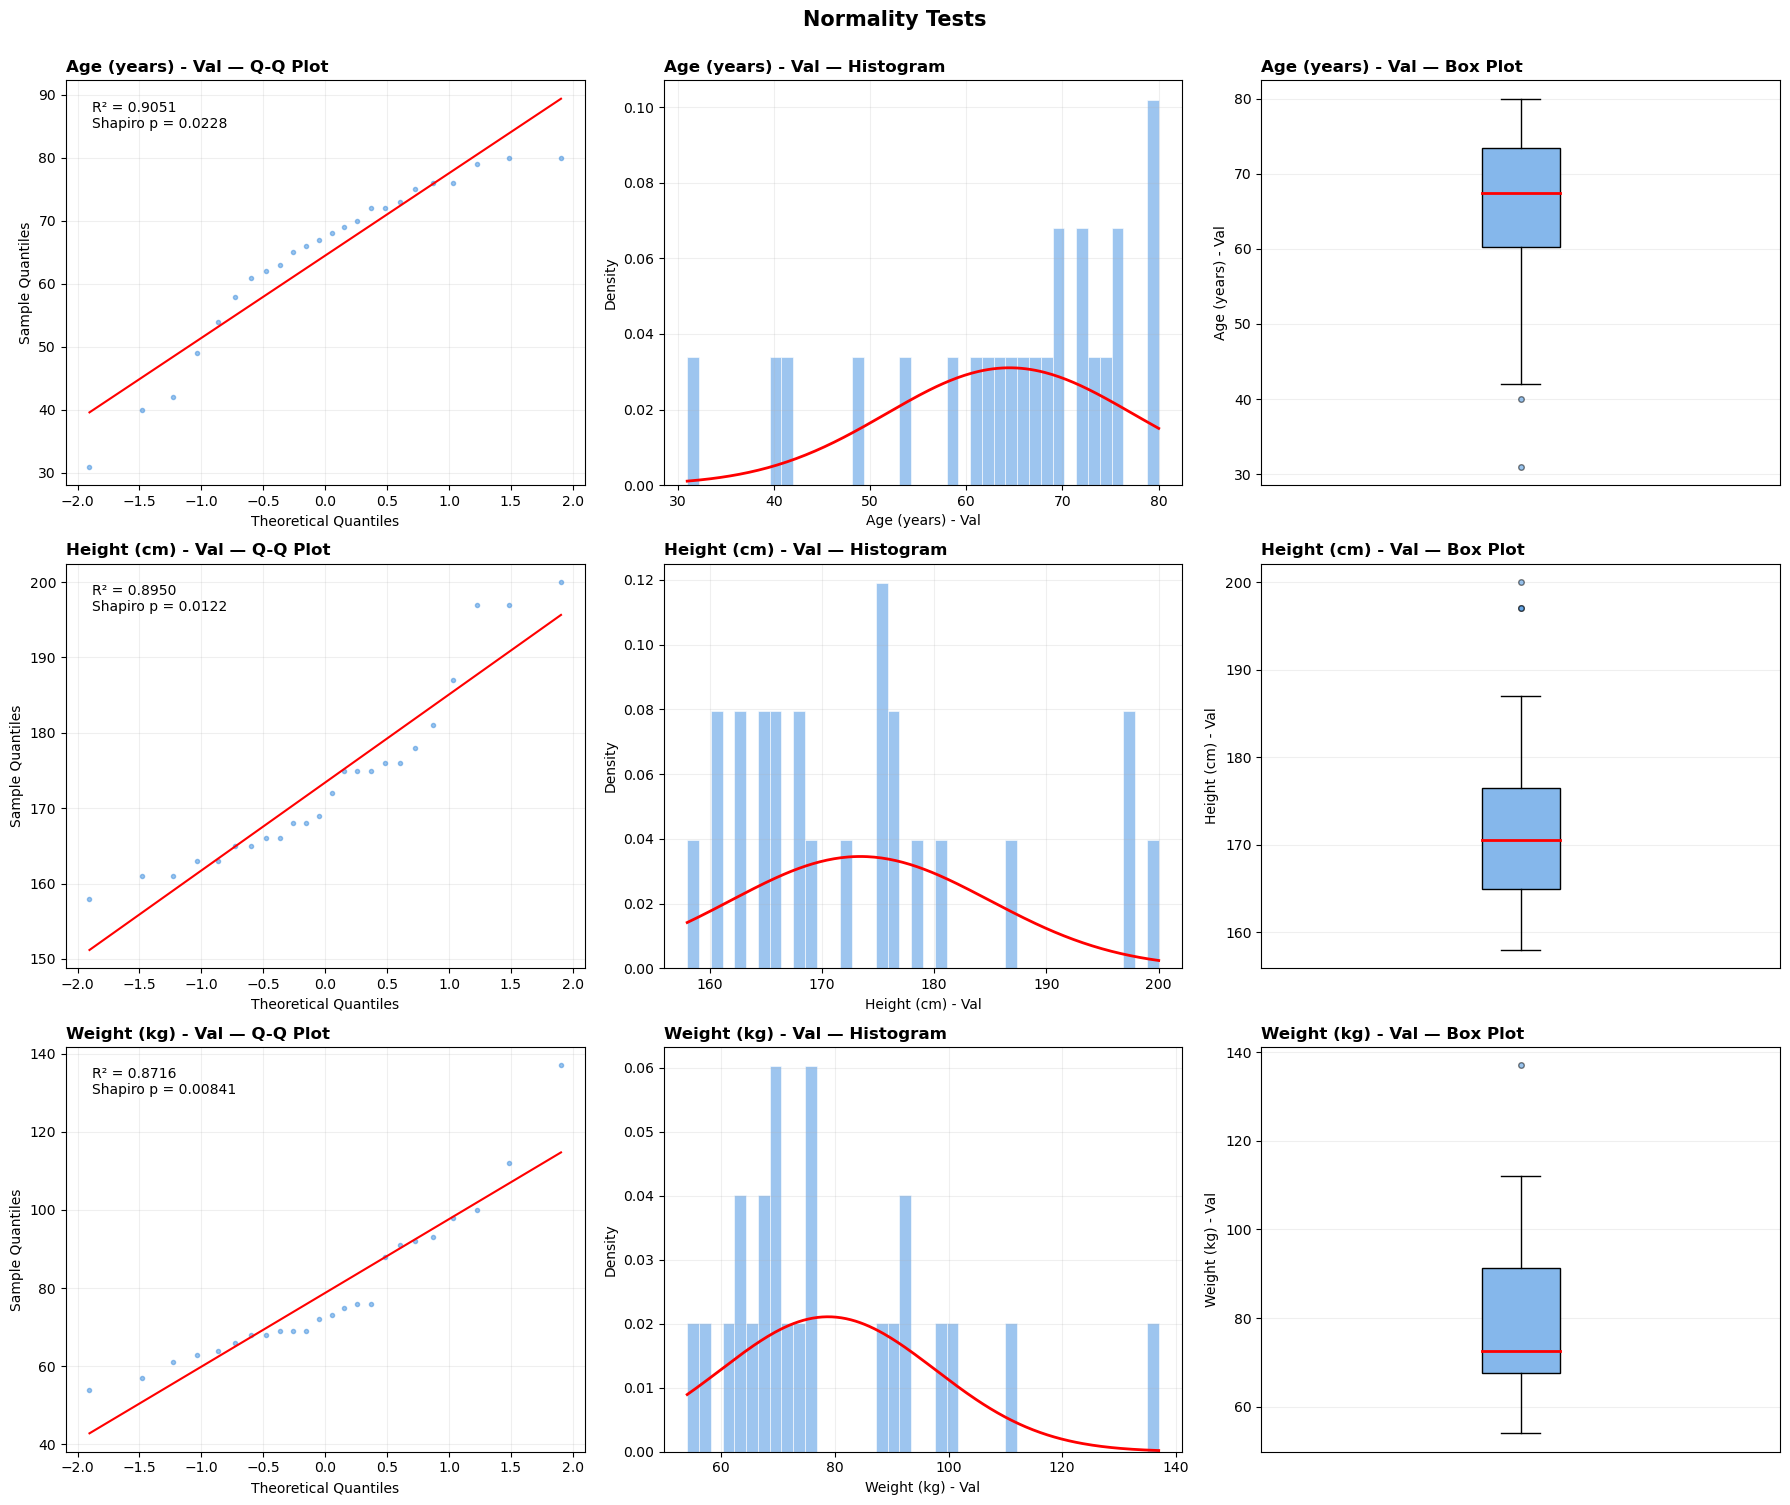

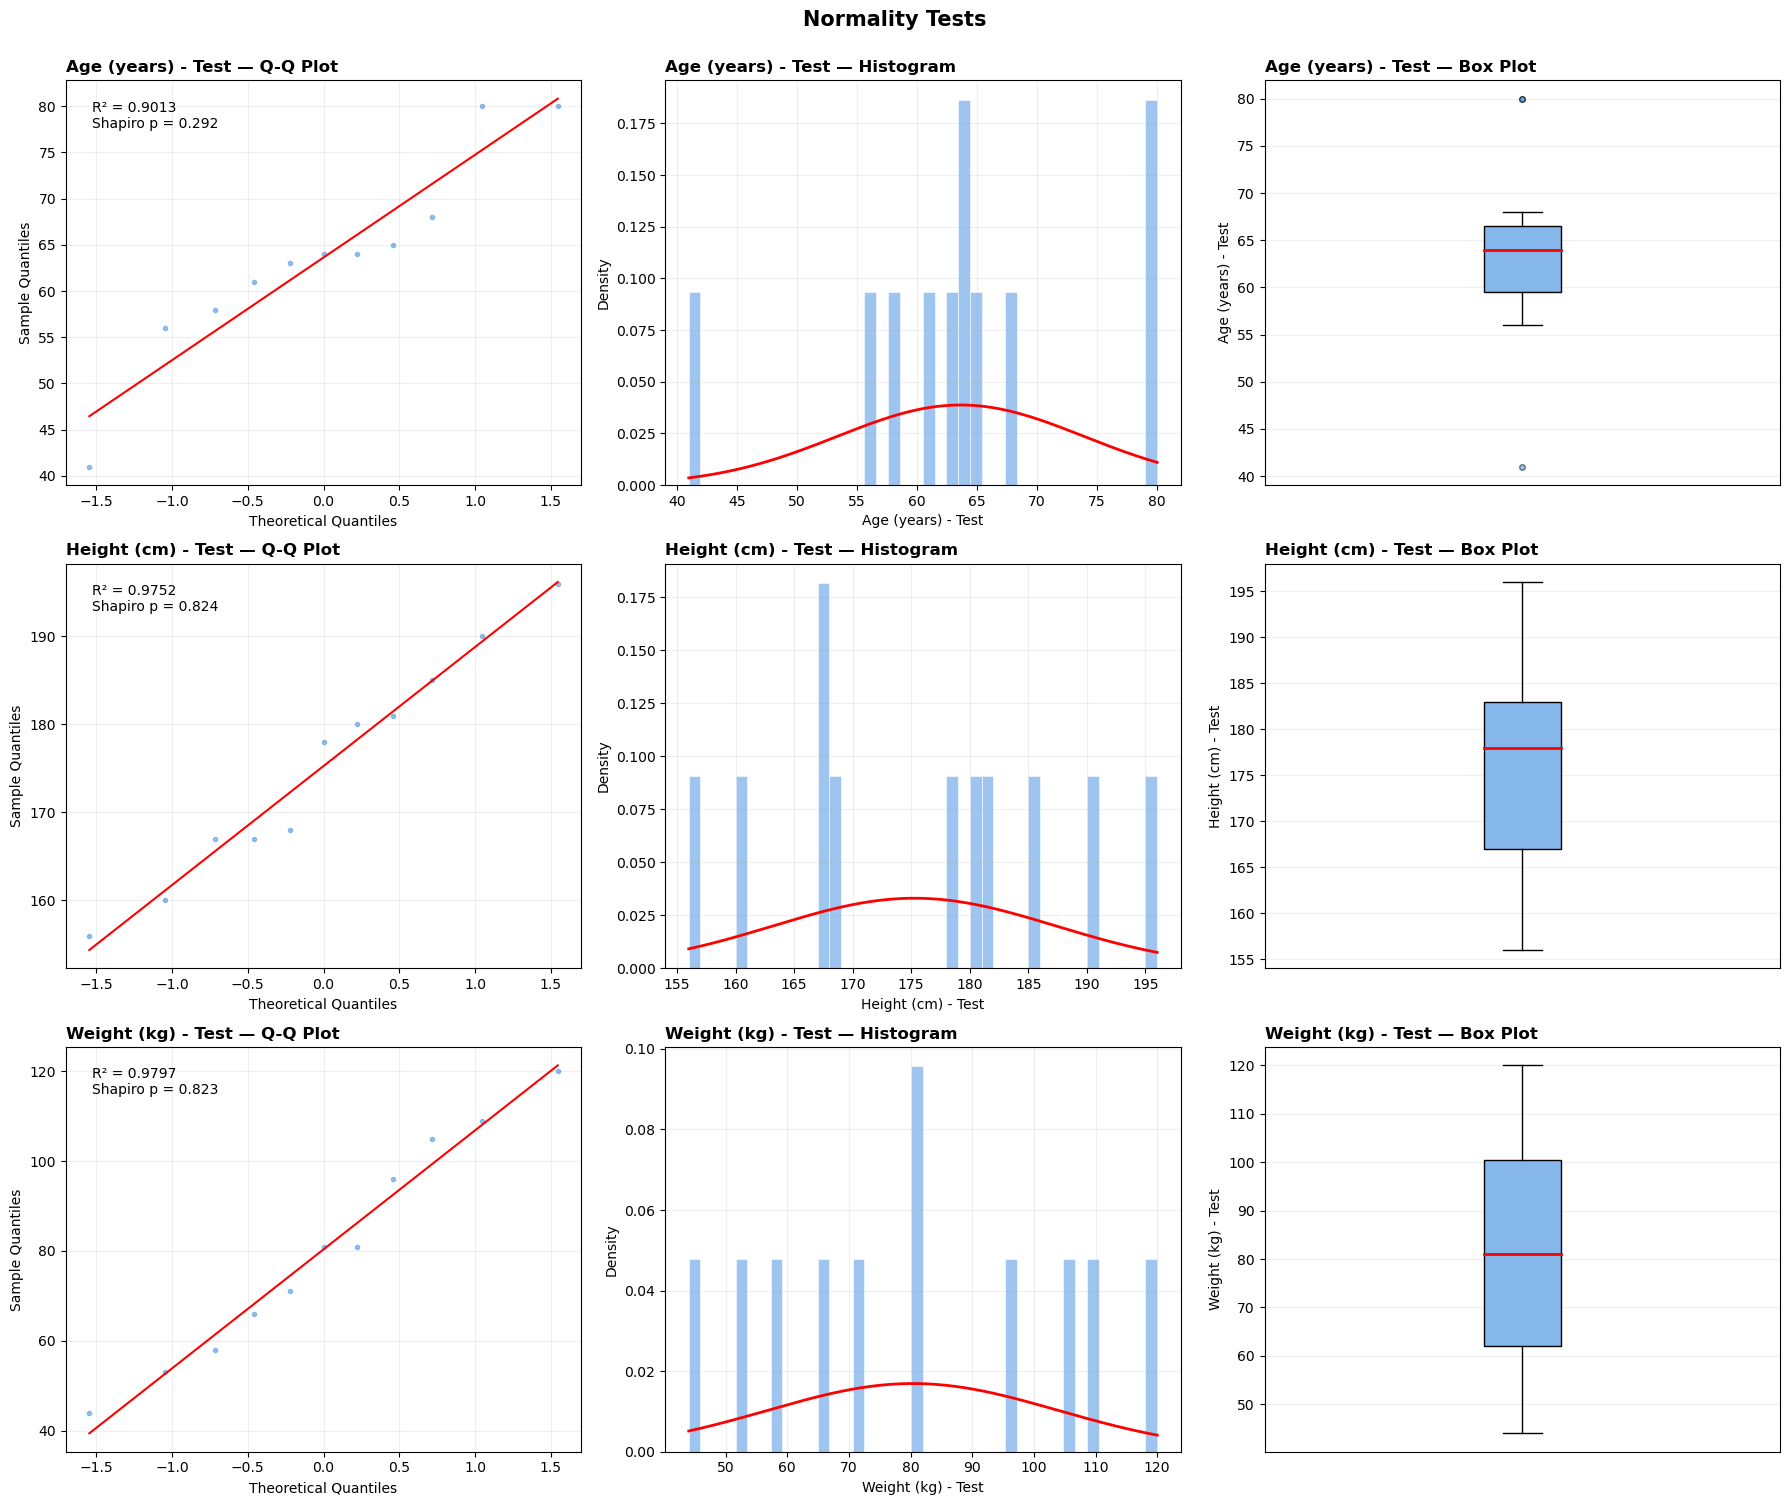

,Characteristic,Train (n=59),Val (n=24),Test (n=11)
0,"Age, median (IQR), years",67.0 (62.0-73.0),67.5 (60.2-73.5),64.0 (59.5-66.5)
1,"Height, median (IQR), cm",174.0 (167.5-180.5),170.5 (165.0-176.5),178.0 (167.0-183.0)
2,"Sex, number male (%)",23 (38.98),10 (41.67),6 (54.55)
3,"Weight, median (IQR), kg",76.0 (64.0-87.0),72.5 (67.5-91.2),81.0 (62.0-100.5)


In [ ]:
labels = {'age_at_surgery': 'Age (years)', 'dem_height': 'Height (cm)', 'dem_weight': 'Weight (kg)'}

def make_summary(df, dataset_name):
    summary = []
    
    # Age
    data = df['age_at_surgery'].dropna()
    summary.append({
        'Characteristic': 'Age, median (IQR), years',
        dataset_name: f'{data.median():.1f} ({data.quantile(0.25):.1f}-{data.quantile(0.75):.1f})'
    })
    
    # Height
    data = df['dem_height'].dropna()
    summary.append({
        'Characteristic': 'Height, median (IQR), cm',
        dataset_name: f'{data.median():.1f} ({data.quantile(0.25):.1f}-{data.quantile(0.75):.1f})'
    })

    # Sex
    n_total = df['dem_sex'].notna().sum()
    n_male = (df['dem_sex'] == 1).sum()
    summary.append({
        'Characteristic': 'Sex, number male (%)',
        dataset_name: f'{n_male} ({100 * n_male / n_total:.2f})'
    })

    # Weight
    data = df['dem_weight'].dropna()
    summary.append({
        'Characteristic': 'Weight, median (IQR), kg',
        dataset_name: f'{data.median():.1f} ({data.quantile(0.25):.1f}-{data.quantile(0.75):.1f})'
    })

    return pd.DataFrame(summary)

# Loading indices and determining patients per split
pad = os.path.join(DATA_PATH, STAT_PATH, 'npy_files')
load = lambda name: np.load(os.path.join(pad, name))

np_c = load('np_c_finetune.npy')
indices = {
    'Train': load('indices_train_260610.npy'),
    'Val':   load('indices_val_260610.npy'),
    'Test':  load('indices_test_260610.npy'),
}
patients = {split: np.unique(np_c[idx]) for split, idx in indices.items()}

# Demographic data loading and splitting per split
df_demo = pd.read_csv(os.path.join(DATA_PATH, 'df_baseline.csv'), sep=';')
df_demo['dem_sex'] = (df_demo['dem_sex'].str.strip() == 'Male').astype(int)
df_demo = df_demo.rename(columns={df_demo.columns[0]: 'patient_id'})

dfs = {split: df_demo[df_demo['patient_id'].isin(ids)]
       for split, ids in patients.items()}

# Normality tests per split
for split, df in dfs.items():
    test_normal_distribution(
        [(df[col].values, f'{name} - {split}') for col, name in labels.items()]
    )

# Summary
df_summary = None
for split, df in dfs.items():
    df_sum = make_summary(df, f'{split} (n={len(df)})')
    df_summary = df_sum if df_summary is None else df_summary.merge(df_sum, on='Characteristic')

display(df_summary)

### <center><b> Mann-Whitney U test for comparison between groups


In [10]:
# Mann-Whitney U test
variables = {'age_at_surgery': 'Age', 'dem_height': 'Length', 'dem_weight': 'Weight'}
pairs = [('Train', 'Val'), ('Train', 'Test'), ('Val', 'Test')]

print('\nMann-Whitney U test')
header = f'{"Variable":<10}' + ''.join(f'{f"{a}-{b} p":>14}' for a, b in pairs)
print(header)
print('-' * len(header))

for col, name in variables.items():
    ps = [mannwhitneyu(dfs[a][col].dropna(), dfs[b][col].dropna()).pvalue
          for a, b in pairs]
    print(f'{name:<10}' + ''.join(f'{p:>14.4f}' for p in ps))

# Chi-kwadraat for sex
table = np.array([[df['dem_sex'].sum(), len(df) - df['dem_sex'].sum()]
                  for df in dfs.values()])
chi2, p, dof, _ = chi2_contingency(table)

print('\nChi-kwadraat test sex')
print(f'Chi-kwadraat: {chi2:.4f}, p = {p:.4f}')


Mann-Whitney U test
Variable     Train-Val p  Train-Test p    Val-Test p
----------------------------------------------------
Age               0.7174        0.1989        0.5219
Length            0.3816        0.7774        0.5813
Weight            0.9719        0.8275        0.8589

Chi-kwadraat test sex
Chi-kwadraat: 0.9254, p = 0.6296
